In [ ]:
import MetaTrader5 as mt5
from datetime import datetime
import pandas as pd
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor


import optuna
import numpy as np
import pandas as pd
import yfinance as yf
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

import gymnasium as gym
from gymnasium import spaces

import gc

import optuna
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from wandb.integration.sb3 import WandbCallback
import wandb
from alibi_detect.od import IForest

from stable_baselines3.common.callbacks import BaseCallback
import torch
import os

d:\dev python\OrionTrader\.venv\lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
d:\dev python\OrionTrader\.venv\lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type ali

## Config

In [ ]:
MT5_LOGIN = os.environ.get('MT5_LOGIN')        # ex: 12345678 ou None pour pas d'auth (local)
MT5_PASSWORD = os.environ.get('MT5_PASSWORD')      # placeholder
MT5_SERVER = os.environ.get('MT5_SERVER')     # ex: "MetaQuotes-Demo"
SYMBOL = "EURUSD"       # ajuster
TIMEFRAME = mt5.TIMEFRAME_D1
START = datetime(2020,1,1)
END = datetime(2023,1,1)
MODEL_PATH = "models/best_ppo_forex.zip"  # chemin du modèle sauvegardé
RESUME_TIMESTEPS = 200_000

## Connexion MT5 et récupération historique

In [8]:
if not mt5.initialize():
    raise RuntimeError(f"mt5.initialize() failed: {mt5.last_error()}")
if MT5_LOGIN is not None:
    mt5.login(MT5_LOGIN, password=MT5_PASSWORD, server=MT5_SERVER)

rates = mt5.copy_rates_range(SYMBOL, TIMEFRAME, START, END)
if rates is None or len(rates) == 0:
    mt5.shutdown()
    raise RuntimeError("Aucune données récupérées depuis MT5 pour la période demandée.")

df_mt5 = pd.DataFrame(rates)
df_mt5['time'] = pd.to_datetime(df_mt5['time'], unit='s')
# map columns to format attendu par ForexEnv
if 'close' in df_mt5.columns:
    df_mt5 = df_mt5.rename(columns={'close': 'Close'})

## Créer env compatible déjà utilisé dans notebook

In [11]:
class ForexEnv(gym.Env):
    def __init__(self, df):
        super(ForexEnv, self).__init__()
        self.df = df.reset_index(drop=True)
        self.max_steps = len(df) - 1
        self.current_step = 0

        # Action : 0 = hold, 1 = buy, 2 = sell
        self.action_space = spaces.Discrete(3)

        # Observation : prix actuel et delta précédent
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(2,), dtype=np.float32)

        self.position = 0  # 0 = neutral, 1 = long, -1 = short
        self.entry_price = 0.0

    def reset(self, **kwargs):
        self.current_step = 0
        self.position = 0
        self.entry_price = 0.0
        obs = self._next_obs()
        info = {}
        return obs, info

    def _next_obs(self):
        price = float(self.df.loc[self.current_step, 'Close'])
        delta = float(self.df.loc[self.current_step, 'Close'] - self.df.loc[self.current_step-1, 'Close']) if self.current_step > 0 else 0.0
        obs = np.array([price, delta], dtype=np.float32)
        return obs

    # def step(self, action):
    #     prev_price = float(self.df.loc[self.current_step, 'Close'])
    #     delta = float(prev_price - self.df.loc[self.current_step-1, 'Close']) if self.current_step > 0 else 0.0

    #     # Mettre à jour la position
    #     if action == 1:  # buy
    #         self.position = 1
    #     elif action == 2:  # sell
    #         self.position = -1
    #     # hold (0) garde self.position inchangé

    #     # reward basé sur delta et position courante
    #     reward = delta * self.position * 1000  # multiplier pour une échelle plus grande

    #     self.current_step += 1
    #     terminated = self.current_step >= len(self.df) - 1
    #     truncated = False
    #     price = float(self.df.loc[self.current_step, 'Close']) if not terminated else prev_price
    #     obs = np.array([price, delta], dtype=np.float32)
    #     info = {}

    #     return obs, float(reward), terminated, truncated, info
    
    def step(self, action):
        prev_price = float(self.df.loc[self.current_step, 'Close'])
        self.current_step += 1
        terminated = self.current_step >= len(self.df) - 1
        price = float(self.df.loc[self.current_step, 'Close'])
        delta = price - prev_price

        # Actions : 0 hold, 1 buy, 2 sell, 3 close
        if action == 1:
            self.position = 1
        elif action == 2:
            self.position = -1
        elif action == 3:
            self.position = 0

        reward = delta * self.position * 1000  # amplifié pour stabilité

        obs = np.array([price, delta], dtype=np.float32)
        info = {}
        truncated = False
        return obs, reward, terminated, truncated, info




In [12]:
def make_mt5_env():
    return lambda: Monitor(ForexEnv(df_mt5))

env = DummyVecEnv([make_mt5_env()])

## model

📊 Évaluation avant entraînement (stochastique):
  mean_reward: 4.330, std: 79.626
  episode rewards: [-31.08, 49.04, -207.66, 40.7, 29.74, 52.8, -43.98, 15.28, 66.58, 71.88]
Eval num_timesteps=510736, episode_reward=109.78 +/- 31.19
Episode length: 779.00 +/- 0.00
New best mean reward!
Eval num_timesteps=520736, episode_reward=70.48 +/- 110.73
Episode length: 779.00 +/- 0.00
Eval num_timesteps=530736, episode_reward=111.25 +/- 70.45
Episode length: 779.00 +/- 0.00
New best mean reward!
Eval num_timesteps=540736, episode_reward=3.39 +/- 78.27
Episode length: 779.00 +/- 0.00
Eval num_timesteps=550736, episode_reward=59.41 +/- 57.22
Episode length: 779.00 +/- 0.00
Eval num_timesteps=560736, episode_reward=37.64 +/- 61.14
Episode length: 779.00 +/- 0.00
Eval num_timesteps=570736, episode_reward=35.36 +/- 56.70
Episode length: 779.00 +/- 0.00
Eval num_timesteps=580736, episode_reward=52.44 +/- 75.37
Episode length: 779.00 +/- 0.00
Eval num_timesteps=590736, episode_reward=82.35 +/- 66.18
Ep

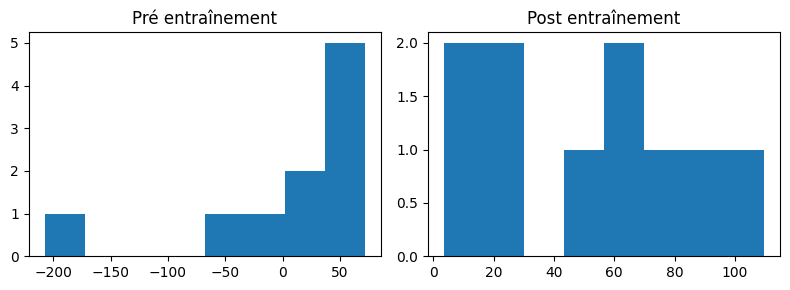

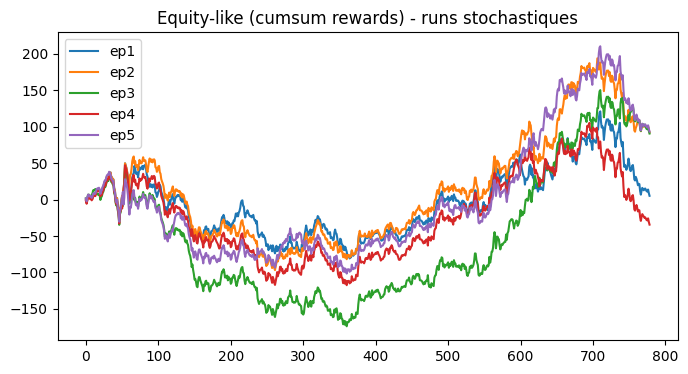

✅ Modèle sauvegardé: models/metatrader_ppo_resumed.zip


True

In [15]:
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from stable_baselines3.common.vec_env import VecEnvWrapper

# wrapper qui choisit un start aléatoire avant reset
class RandomStartWrapper(gym.Wrapper):
    def __init__(self, env, min_offset=1, max_offset=None):
        super().__init__(env)
        self.min_offset = min_offset
        self.max_offset = max_offset

    def reset(self, **kwargs):
        max_off = self.max_offset if self.max_offset is not None else max(1, self.env.unwrapped.max_steps // 10)
        start_idx = random.randint(self.min_offset, max_off)
        # positionner current_step puis appeler reset pour générer l'observation
        self.env.unwrapped.current_step = start_idx
        return self.env.reset(**kwargs)

# factory qui retourne env avec random start
def make_mt5_env_random():
    return lambda: Monitor(RandomStartWrapper(ForexEnv(df_mt5), min_offset=1, max_offset=200))

# charger modèle
best_model = PPO.load(MODEL_PATH, env=env)

# éval pré-entrainement non-déterministe
eval_env_pre = DummyVecEnv([make_mt5_env_random()])
pre_rewards, _ = evaluate_policy(best_model, eval_env_pre, n_eval_episodes=10, deterministic=False, return_episode_rewards=True)
print("📊 Évaluation avant entraînement (stochastique):")
print(f"  mean_reward: {np.mean(pre_rewards):.3f}, std: {np.std(pre_rewards):.3f}")
print(f"  episode rewards: {pre_rewards}")

# préparer eval_env pour callback (stochastique)
eval_env = DummyVecEnv([make_mt5_env_random()])

# dossier pour sauvegarder meilleurs modèles durant l'éval
best_eval_dir = "models/eval_mt5"
os.makedirs(best_eval_dir, exist_ok=True)

# EvalCallback en non-deterministic pour refléter la variance réelle
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=best_eval_dir,
    log_path=best_eval_dir,
    eval_freq=10_000,
    n_eval_episodes=5,
    deterministic=False,
    render=False,
)

# entraînement (reprendre)
best_model.learn(
    total_timesteps=RESUME_TIMESTEPS,
    reset_num_timesteps=False,
    callback=eval_callback,
)

# éval post-entrainement non-déterministe
eval_env_post = DummyVecEnv([make_mt5_env_random()])
post_rewards, _ = evaluate_policy(best_model, eval_env_post, n_eval_episodes=10, deterministic=False, return_episode_rewards=True)
print("📊 Évaluation après entraînement (stochastique):")
print(f"  mean_reward: {np.mean(post_rewards):.3f}, std: {np.std(post_rewards):.3f}")
print(f"  episode rewards: {post_rewards}")

# tracer distribution pré / post
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.hist(pre_rewards, bins=8)
plt.title("Pré entraînement")
plt.subplot(1,2,2)
plt.hist(post_rewards, bins=8)
plt.title("Post entraînement")
plt.tight_layout()
plt.show()

# run manuel (equity-like) pour visualiser pas-à-pas
def run_and_collect(model, env_inst, n_episodes=3):
    all_eps = []
    for _ in range(n_episodes):
        obs, _ = env_inst.reset()
        done = False
        ep_rewards = []
        while not done:
            action, _ = model.predict(obs, deterministic=False)
            obs, reward, terminated, truncated, info = env_inst.step(action)
            ep_rewards.append(float(np.mean(reward) if isinstance(reward, (list, np.ndarray)) else reward))
            done = bool(terminated or truncated)
        all_eps.append(ep_rewards)
    return all_eps

single_env = Monitor(RandomStartWrapper(ForexEnv(df_mt5)))
episodes = run_and_collect(best_model, single_env, n_episodes=5)
# plot equity per episode
plt.figure(figsize=(8,4))
for i, ep in enumerate(episodes):
    plt.plot(np.cumsum(ep), label=f"ep{i+1}")
plt.title("Equity-like (cumsum rewards) - runs stochastiques")
plt.legend()
plt.show()
single_env.close()

# sauvegarder et cleanup
out_path = "models/metatrader_ppo_resumed.zip"
best_model.save(out_path)
print(f"✅ Modèle sauvegardé: {out_path}")
env.close()
eval_env.close()
mt5.shutdown()